# Natural Language Processing. Assignment 1. Tokenization.

In this assignment, you need to implement, train, and analyze a Byte-Pair Encoding (BPE) tokenizer.

The assignment consist of 3 tasks. When you finish all the tasks, create a GitHub repository for this assignment (you can use this repository later for the other assignments) and submit this notebook in the repository. Leave `requirements.txt` file if your code requires additional installations. Submit the link to the repository in Moodle.

## Task 1: Data Preparation and Vocabulary Size Selection (3 points)

First, load the [Brown corpus](https://en.wikipedia.org/wiki/Brown_Corpus). After loading the corpus, you need to select the appropriate vocabulary size for the BPE tokenizer. The appropriate vocabulary size is the minimal vocabulary size that covers at least 90% of the words in the corpus. The coverage is calculated according to the following formula:



$$ \text{coverage}(k) = \frac{\sum_{r=1}^{k} f(r)}{\sum_{r=1}^{N} f(r)} $$



where $f(r)$ is the frequency of the top-$r$ word, $k$ is the number of top-$k$ tokens included in vocab, $N$ is the total unique words in corpus.

So, for this task you need to do the following:

1. Load the Brown corpus (0.5 points)
2. Plot cumulative coverage vs. vocabulary size for the loaded corpus (1 point)
3. Select the appropriate vocabulary size (0.5 point)
4. Answer the questions:
    1. Why the coverage slows down the increase as the vocabulary size increases? (0.5 point)
    2. Which empirical law explains the slowing down increase of the coverage? (0.5 point)

Total words in corpus: 1161192
Total sentences in corpus: 57340
Total unique words (N): 56057


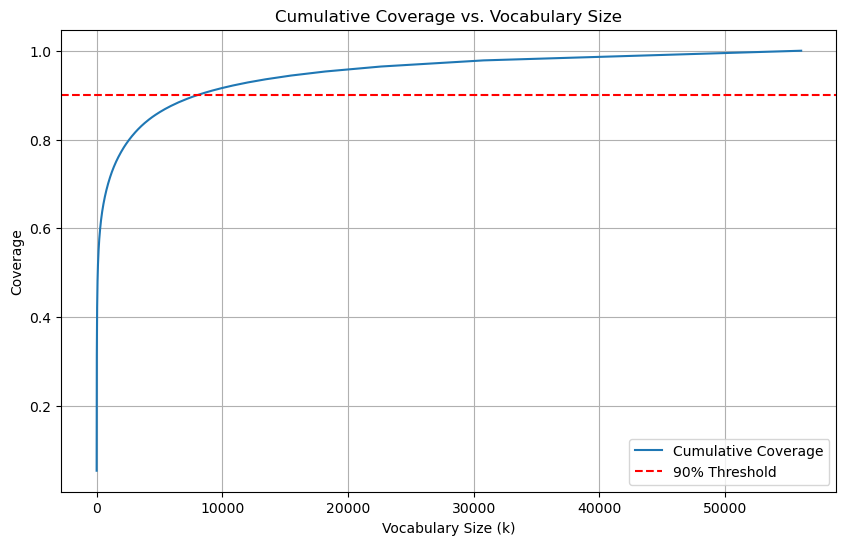

In [16]:
import nltk
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import brown
from collections import Counter

# Download the corpus
nltk.download("brown", quiet=True)

# Load the Brown corpus
sentences = brown.sents()
words = brown.words()
print(f"Total words in corpus: {len(words)}")
print(f"Total sentences in corpus: {len(sentences)}")

# Count word frequencies
word_counts = Counter(words)
print(f"Total unique words (N): {len(word_counts)}")

# Sort words by frequency
# f(r) is the frequency of the word at rank r
sorted_counts = word_counts.most_common()
frequencies = np.array([freq for word, freq in sorted_counts])

# Calculate cumulative coverage: sum(top-k freqs) / sum(total freqs)
total_tokens = np.sum(frequencies)
cumulative_frequencies = np.cumsum(frequencies)
coverage = cumulative_frequencies / total_tokens

# Plot cumulative coverage
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(coverage) + 1), coverage, label="Cumulative Coverage")
plt.axhline(y=0.9, color="r", linestyle="--", label="90% Threshold")
plt.xlabel("Vocabulary Size (k)")
plt.ylabel("Coverage")
plt.title("Cumulative Coverage vs. Vocabulary Size")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
# Select appropriate vocab size (>= 0.9)
k_90 = np.searchsorted(coverage, 0.9) + 1

print(f"Vocabulary size for 90% coverage: {k_90}")
print(f"Percentage of total unique words needed: {k_90 / len(word_counts) * 100:.2f}%")

Vocabulary size for 90% coverage: 8012
Percentage of total unique words needed: 14.29%


1. **Why the coverage slows down the increase as the vocabulary size increases?**

- The coverage slows down because natural language follows a long-tail distribution. The few most frequent words (like "the", "of", "and") appear extremely often and contribute significantly to the total count;
- However, as $k$ increases, we encounter words that appear very rarely. Adding these rare words to the vocabulary increases the cumulative numerator ($ \sum f(r) $) by a very small amount, resulting in a plateau in the coverage curve.

2.  **Which empirical law explains the slowing down increase of the coverage?**

- **Zipf's Law**. It states that the frequency of any given word is inversely proportional to its rank in the frequency table ($ f(r) \propto 1/r $).

## Task 2: Implement Byte-Pair Encoding (BPE) Tokenizer (4 points)

Implement the [BPE tokenizer](https://arxiv.org/pdf/1508.07909) as the `BPETokenizer` class.

The class should contain correctly implemented:

* `train` method (1.5 points).
* `tokenize` method (1.5 points).

The code should have docstrings and comments (1 point).

In [13]:
import re
from collections import Counter, defaultdict


class BPETokenizer:
    """
    This class implements the BPE algorithm for subword tokenization.
    It learns a merge table from a corpus to segment words into subword units.
    """

    def __init__(self, vocab_size=1000):
        """
        Initialize the tokenizer.

        Args:
            vocab_size (int): The target vocabulary size.
            end_sym (str): The symbol to append to the end of each word.
        """
        self.vocab_size = vocab_size
        self.end_sym = "</w>"
        self.merges = {}  # Stores merge rules: (token1, token2) -> rank
        self.vocab = set()  # Stores valid tokens

    def _get_stats(self, vocab_counts):
        """
        Compute frequency of all adjacent symbol pairs in the current vocabulary.

        Args:
            vocab_counts (Counter): Mapping of space-separated tokens to frequency.

        Returns:
            defaultdict: Frequency of each pair.
        """
        pairs = defaultdict(int)
        for word, freq in vocab_counts.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[symbols[i], symbols[i + 1]] += freq
        return pairs

    def _merge_vocab(self, pair, vocab_counts):
        """
        Apply a merge operation to the current vocabulary dictionary.

        Args:
            pair (tuple): The pair of symbols to merge.
            vocab_counts (Counter): Current vocabulary counts.

        Returns:
            Counter: Updated vocabulary counts with the pair merged.
        """
        v_out = {}

        # Escape characters to safely use them in regex
        bigram = re.escape(" ".join(pair))
        p = re.compile(r"(?<!\S)" + bigram + r"(?!\S)")

        # New token replaces the space between the pair
        replacement = "".join(pair)

        for word in vocab_counts:
            # Replace occurrences of the pair in the word
            w_out = p.sub(replacement, word)
            v_out[w_out] = vocab_counts[word]

        return v_out

    def train(self, corpus):
        """
        Train the BPE tokenizer on a given corpus.

        Args:
            corpus (list): A list of strings or words.
        """
        print("Preprocessing corpus...")
        # Pre-tokenize by splitting by space and appending end symbol
        initial_words = Counter()

        # Determine if input is list of sentences or list of words
        for item in corpus:
            # If item contains spaces, we treat it as a sentence and split
            if " " in item:
                words = item.split()
            else:
                words = [item]

            for w in words:
                # Initialize as space-separated chars: "l o w </w>"
                initial_words[" ".join(list(w) + [self.end_sym])] += 1

        self.vocab = set()
        # Add initial characters to vocab
        for w in initial_words:
            self.vocab.update(w.split())

        vocab_counts = initial_words.copy()
        print(f"Initial vocab: {vocab_counts.most_common(5)}")

        num_merges = 0
        print(f"Starting BPE training. Target vocab size: {self.vocab_size}")

        # Perform merges until we reach the target vocabulary size
        while len(self.vocab) < self.vocab_size:
            pairs = self._get_stats(vocab_counts)

            if not pairs:
                break

            # Find the most frequent pair
            best_pair = max(pairs, key=pairs.get)

            # Record the merge
            self.merges[best_pair] = num_merges

            # Update vocabulary counts
            vocab_counts = self._merge_vocab(best_pair, vocab_counts)

            # Add the new token to the vocabulary set
            new_token = "".join(best_pair)
            self.vocab.add(new_token)

            num_merges += 1
            if num_merges % 100 == 0:
                print(
                    f"Merge #{num_merges}: {best_pair} -> {new_token}. Vocab size: {len(self.vocab)}"
                )

        print(
            f"Training complete. Final rules: {len(self.merges)}, Final vocab: {len(self.vocab)}"
        )

    def _encode_word(self, word):
        """
        Tokenize a single word using the learned BPE rules.

        Args:
            word (str): The word to tokenize.

        Returns:
            list: List of BPE subwords.
        """
        # Start with characters
        word_tokens = list(word) + [self.end_sym]

        while True:
            # Get all adjacent pairs
            pairs = [
                (word_tokens[i], word_tokens[i + 1])
                for i in range(len(word_tokens) - 1)
            ]

            if not pairs:
                break

            # Find the pair that was merged earliest (lowest rank)
            valid_pairs = [
                (pair, self.merges[pair]) for pair in pairs if pair in self.merges
            ]

            if not valid_pairs:
                break

            # Select pair with min rank
            best_pair = min(valid_pairs, key=lambda x: x[1])[0]

            # Merge the best pair in the word_tokens list
            new_tokens = []
            i = 0
            while i < len(word_tokens):
                if (
                    i < len(word_tokens) - 1
                    and (word_tokens[i], word_tokens[i + 1]) == best_pair
                ):
                    new_tokens.append(best_pair[0] + best_pair[1])
                    i += 2
                else:
                    new_tokens.append(word_tokens[i])
                    i += 1
            word_tokens = new_tokens

        return word_tokens

    def tokenize(self, text):
        """
        Tokenize raw text.

        Args:
            text (str): Input text string.

        Returns:
            list: Tokenized text.
        """
        # Split by whitespace
        words = text.split()
        bpe_tokens = []

        for word in words:
            # Encode each word individually
            word_subwords = self._encode_word(word)
            bpe_tokens.extend(word_subwords)

        return bpe_tokens

## Task 3: Tokenizer Training and Analysis (3 points)

1. Train the `BPETokenizer` on the Brown corpus with the appropriate vocabulary size selected in Task 1 (1 points)
2. Use the Brown corpus (1000 samples) to calculate the mean and standard deviation of
    * tokenizer's fertility (1 points)
    * length of the tokenized sentence (1 points)

In [22]:
bpe_tokenizer = BPETokenizer(vocab_size=k_90)

split_ratio = 0.9
split_idx = int(len(sentences) * split_ratio)

train_sentences = sentences[:split_idx]
test_sentences = sentences[split_idx:]
train_corpus = [" ".join(sent) for sent in train_sentences]
test_corpus = [" ".join(sent) for sent in test_sentences]

bpe_tokenizer.train(train_corpus)

Preprocessing corpus...
Initial vocab: [('t h e </w>', 58827), (', </w>', 52868), ('. </w>', 44527), ('o f </w>', 34324), ('a n d </w>', 25511)]
Starting BPE training. Target vocab size: 8012
Merge #100: ('l', 'e') -> le. Vocab size: 184
Merge #200: ('en', 't') -> ent. Vocab size: 284
Merge #300: ('a', 'in') -> ain. Vocab size: 384
Merge #400: ('tw', 'o</w>') -> two</w>. Vocab size: 484
Merge #500: ('N', 'e') -> Ne. Vocab size: 584
Merge #600: ('s', 'l') -> sl. Vocab size: 684
Merge #700: ('mi', 'ght</w>') -> might</w>. Vocab size: 784
Merge #800: ('ac', 't</w>') -> act</w>. Vocab size: 884
Merge #900: ('st', 'at') -> stat. Vocab size: 984
Merge #1000: ('ever', 'y</w>') -> every</w>. Vocab size: 1084
Merge #1100: ('su', 'cc') -> succ. Vocab size: 1184
Merge #1200: ('pro', 'f') -> prof. Vocab size: 1284
Merge #1300: ('de', 'f') -> def. Vocab size: 1384
Merge #1400: ('C', 'ol') -> Col. Vocab size: 1484
Merge #1500: ('g', 'ave</w>') -> gave</w>. Vocab size: 1584
Merge #1600: ('fer', 'ence

Now let's evaluate the trained BPE tokenizer using 1000 samples from the test set. We are interested in two main metrics:

- **Fertility:** The ratio of the number of subwords (BPE tokens) to the number of original words;
- **Sentence Length:** The total number of tokens per sentence after BPE tokenization.

Evaluating on 1000 samples...
------------------------------
Fertility Mean: 1.2561
Fertility Std:  0.2156
------------------------------
Tokenized Length Mean: 21.69
Tokenized Length Std:  14.84
------------------------------


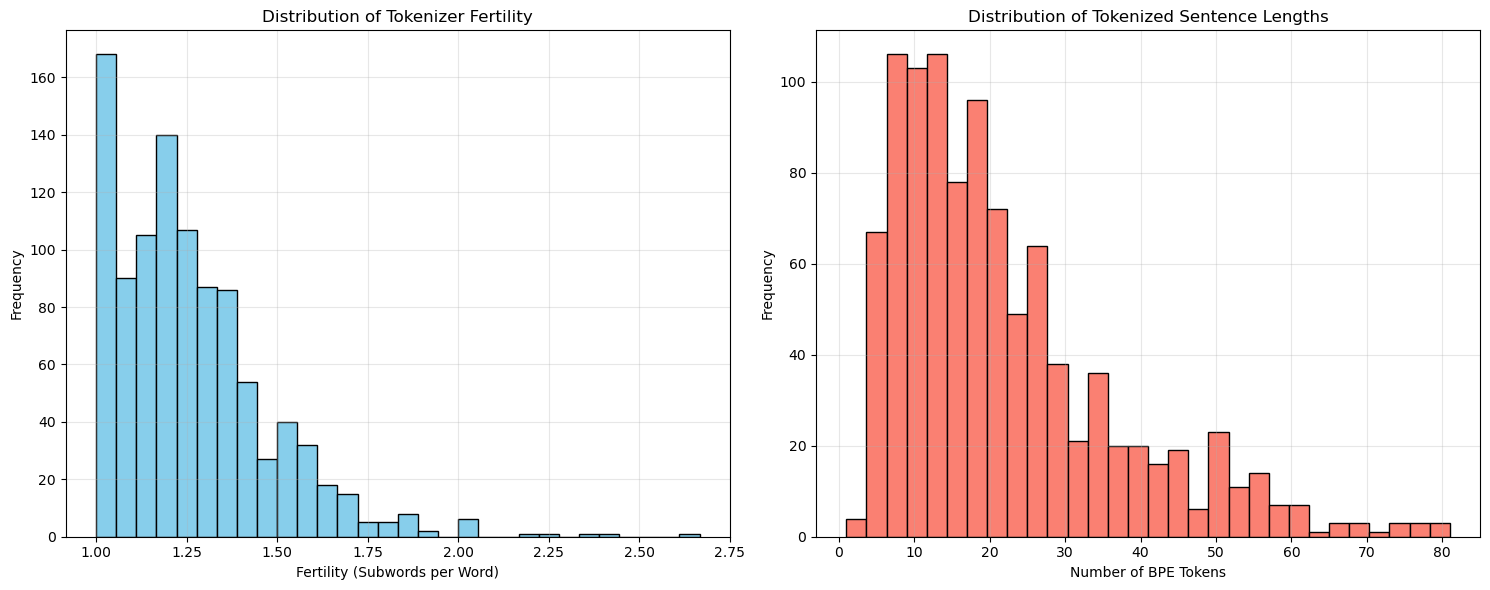

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Select 1000 samples
samples = test_corpus[:1000]

fertilities = []
tokenized_lengths = []

print(f"Evaluating on {len(samples)} samples...")

for sentence in samples:
    # Original words
    original_words = sentence.split()
    if not original_words:
        continue
        
    # Apply BPE tokenization
    bpe_tokens = bpe_tokenizer.tokenize(sentence)
    
    # Calculate length
    seq_len = len(bpe_tokens)
    tokenized_lengths.append(seq_len)
    
    # Calculate fertility
    fertility = seq_len / len(original_words)
    fertilities.append(fertility)

# Convert to numpy arrays for statistics
fertilities = np.array(fertilities)
tokenized_lengths = np.array(tokenized_lengths)

# Report Statistics
print("-" * 30)
print(f"Fertility Mean: {np.mean(fertilities):.4f}")
print(f"Fertility Std:  {np.std(fertilities):.4f}")
print("-" * 30)
print(f"Tokenized Length Mean: {np.mean(tokenized_lengths):.2f}")
print(f"Tokenized Length Std:  {np.std(tokenized_lengths):.2f}")
print("-" * 30)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot Fertility Distribution
ax[0].hist(fertilities, bins=30, color='skyblue', edgecolor='black')
ax[0].set_title('Distribution of Tokenizer Fertility')
ax[0].set_xlabel('Fertility (Subwords per Word)')
ax[0].set_ylabel('Frequency')
ax[0].grid(True, alpha=0.3)

# Plot Sentence Length Distribution
ax[1].hist(tokenized_lengths, bins=30, color='salmon', edgecolor='black')
ax[1].set_title('Distribution of Tokenized Sentence Lengths')
ax[1].set_xlabel('Number of BPE Tokens')
ax[1].set_ylabel('Frequency')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Grading Procedure Details

During the grading of the completed assignments, a random set of students will be sampled for the **offline assignment defence**. The defence will be arranged shortly after the assignment submission deadline. The particular date and time will be announced later. 

The aim of the assignment defence is to ensure the students understand well their own solutions and know how thier solution works. To check this, the students will be asked various questions about the provided solution. In addition, the students will be asked to run their solution to ensure the solution works without errors.

Examples of questions:

1. How the cumulative coverage is calculated? Why is it called cumulative?
2. What is the rank of a word?
3. How does the BPE tokenizer work? Note: for this question, the students will not be able to see the their own implementation.
4. Why do you consider such vocabulary size appropriate?
5. What is the formula for the fertility of the tokenizer?
6. How do you perform pre-tokenization in your implementation?
7. How do you handle stopwords in the training corpus? Why?
8. etc.

As a result of the assignment defence, the grade for the assignment may be adjusted.